In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%matplotlib inline

In [4]:
# ============================================================
# CELL 1: Import all required libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

print("All libraries imported successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Libraries loaded: sklearn, xgboost, matplotlib, seaborn")

All libraries imported successfully.
Pandas version: 2.2.2
NumPy version: 2.0.2
Libraries loaded: sklearn, xgboost, matplotlib, seaborn


In [6]:
# ============================================================
# CELL 2: Load dataset from Google Drive
# ============================================================

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

df_raw = pd.read_csv(
    "/content/AirQuality.csv",
    sep=";",
    decimal=","
)

# Drop empty columns from trailing semicolons
df_raw = df_raw.loc[:, ~df_raw.columns.str.startswith('Unnamed')]
df_raw = df_raw.dropna(how='all', axis=1)

print("\nDataset loaded successfully from Google Drive.")
print("Shape of dataset:", df_raw.shape)
print("\nColumn names:")
for col in df_raw.columns:
    print(" -", col)

print("\nData types:")
print(df_raw.dtypes)

print("\nFirst 5 rows:")
print(df_raw.head())

print("\nBasic statistics:")
print(df_raw.describe())

print("\nMissing values per column:")
print(df_raw.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Dataset loaded successfully from Google Drive.
Shape of dataset: (9471, 15)

Column names:
 - Date
 - Time
 - CO(GT)
 - PT08.S1(CO)
 - NMHC(GT)
 - C6H6(GT)
 - PT08.S2(NMHC)
 - NOx(GT)
 - PT08.S3(NOx)
 - NO2(GT)
 - PT08.S4(NO2)
 - PT08.S5(O3)
 - T
 - RH
 - AH

Data types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

First 5 rows:
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0    

In [7]:
# ============================================================
# CELL 3: Parse datetime and extract time-based features
# ============================================================

df_raw['DateTime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)

df_raw['Hour']       = df_raw['DateTime'].dt.hour
df_raw['DayOfWeek']  = df_raw['DateTime'].dt.dayofweek
df_raw['Month']      = df_raw['DateTime'].dt.month
df_raw['DayOfMonth'] = df_raw['DateTime'].dt.day

print("\nDateTime column created and time features extracted.")
print("Date range:", df_raw['DateTime'].min(), "to", df_raw['DateTime'].max())
print("\nExtracted features: Hour, DayOfWeek, Month, DayOfMonth")
print("\nSample of time features:")
print(df_raw[['Date', 'Time', 'Hour', 'DayOfWeek', 'Month']].head(10))


DateTime column created and time features extracted.
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00

Extracted features: Hour, DayOfWeek, Month, DayOfMonth

Sample of time features:
         Date      Time  Hour  DayOfWeek  Month
0  10/03/2004  18.00.00  18.0        2.0    3.0
1  10/03/2004  19.00.00  19.0        2.0    3.0
2  10/03/2004  20.00.00  20.0        2.0    3.0
3  10/03/2004  21.00.00  21.0        2.0    3.0
4  10/03/2004  22.00.00  22.0        2.0    3.0
5  10/03/2004  23.00.00  23.0        2.0    3.0
6  11/03/2004  00.00.00   0.0        3.0    3.0
7  11/03/2004  01.00.00   1.0        3.0    3.0
8  11/03/2004  02.00.00   2.0        3.0    3.0
9  11/03/2004  03.00.00   3.0        3.0    3.0


In [8]:
# ============================================================
# CELL 4: Handle missing values and clean the data
# ============================================================

df = df_raw.copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Replace -200 sentinel values with NaN
for col in numeric_cols:
    df[col] = df[col].replace(-200, np.nan)

print("\nSentinel values (-200) replaced with NaN.")
print("Missing values after replacement:")
print(df[numeric_cols].isnull().sum())

# Drop rows where target CO(GT) is missing
df = df.dropna(subset=['CO(GT)'])
print("\nRows with missing target CO(GT) dropped.")

# Fill remaining NaN with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Remaining NaN values filled with column medians.")
print("Final cleaned dataset shape:", df.shape)
print("Total NaN values remaining:", df[numeric_cols].isnull().sum().sum())


Sentinel values (-200) replaced with NaN.
Missing values after replacement:
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
Hour              114
DayOfWeek         114
Month             114
DayOfMonth        114
dtype: int64

Rows with missing target CO(GT) dropped.
Remaining NaN values filled with column medians.
Final cleaned dataset shape: (7674, 20)
Total NaN values remaining: 0


In [9]:
# ============================================================
# CELL 5: Define features and target variable
# ============================================================

target = 'CO(GT)'

feature_cols = [
    'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
    'PT08.S5(O3)', 'T', 'RH', 'AH',
    'Hour', 'DayOfWeek', 'Month', 'DayOfMonth'
]

X = df[feature_cols]
y = df[target]

print("\nTarget variable:", target)
print("Number of features:", len(feature_cols))
print("\nFeature list:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i}. {feat}")

print("\nTarget variable (CO(GT)) statistics:")
print(y.describe())
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Target variable: CO(GT)
Number of features: 16

Feature list:
  1. PT08.S1(CO)
  2. NMHC(GT)
  3. C6H6(GT)
  4. PT08.S2(NMHC)
  5. NOx(GT)
  6. PT08.S3(NOx)
  7. NO2(GT)
  8. PT08.S4(NO2)
  9. PT08.S5(O3)
  10. T
  11. RH
  12. AH
  13. Hour
  14. DayOfWeek
  15. Month
  16. DayOfMonth

Target variable (CO(GT)) statistics:
count    7674.000000
mean        2.152750
std         1.453252
min         0.100000
25%         1.100000
50%         1.800000
75%         2.900000
max        11.900000
Name: CO(GT), dtype: float64

Features shape: (7674, 16)
Target shape: (7674,)


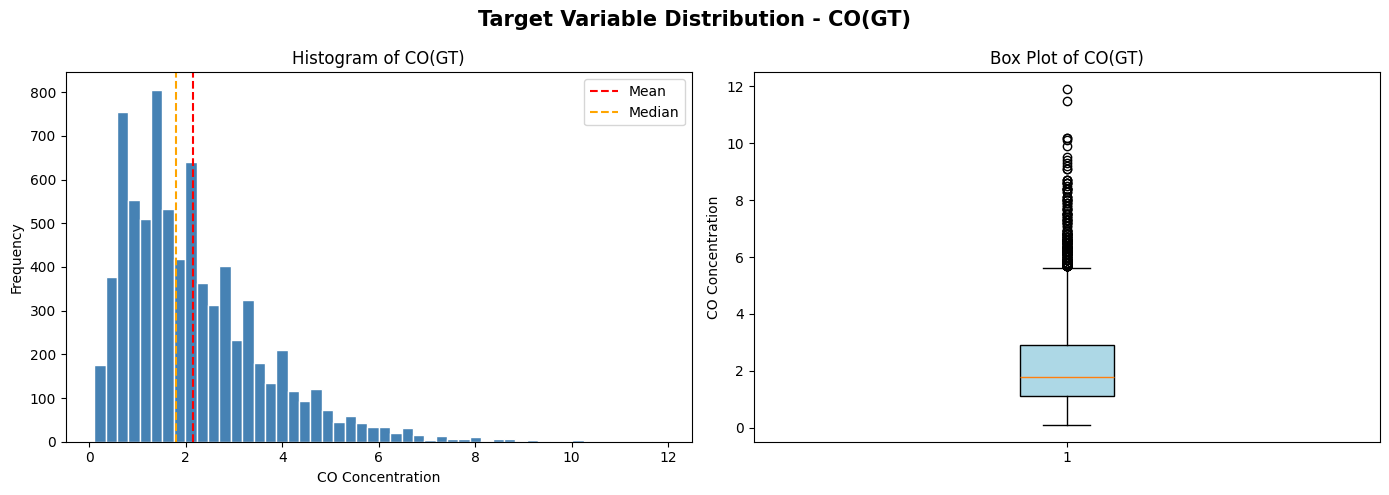

Plot 1 displayed: Target distribution


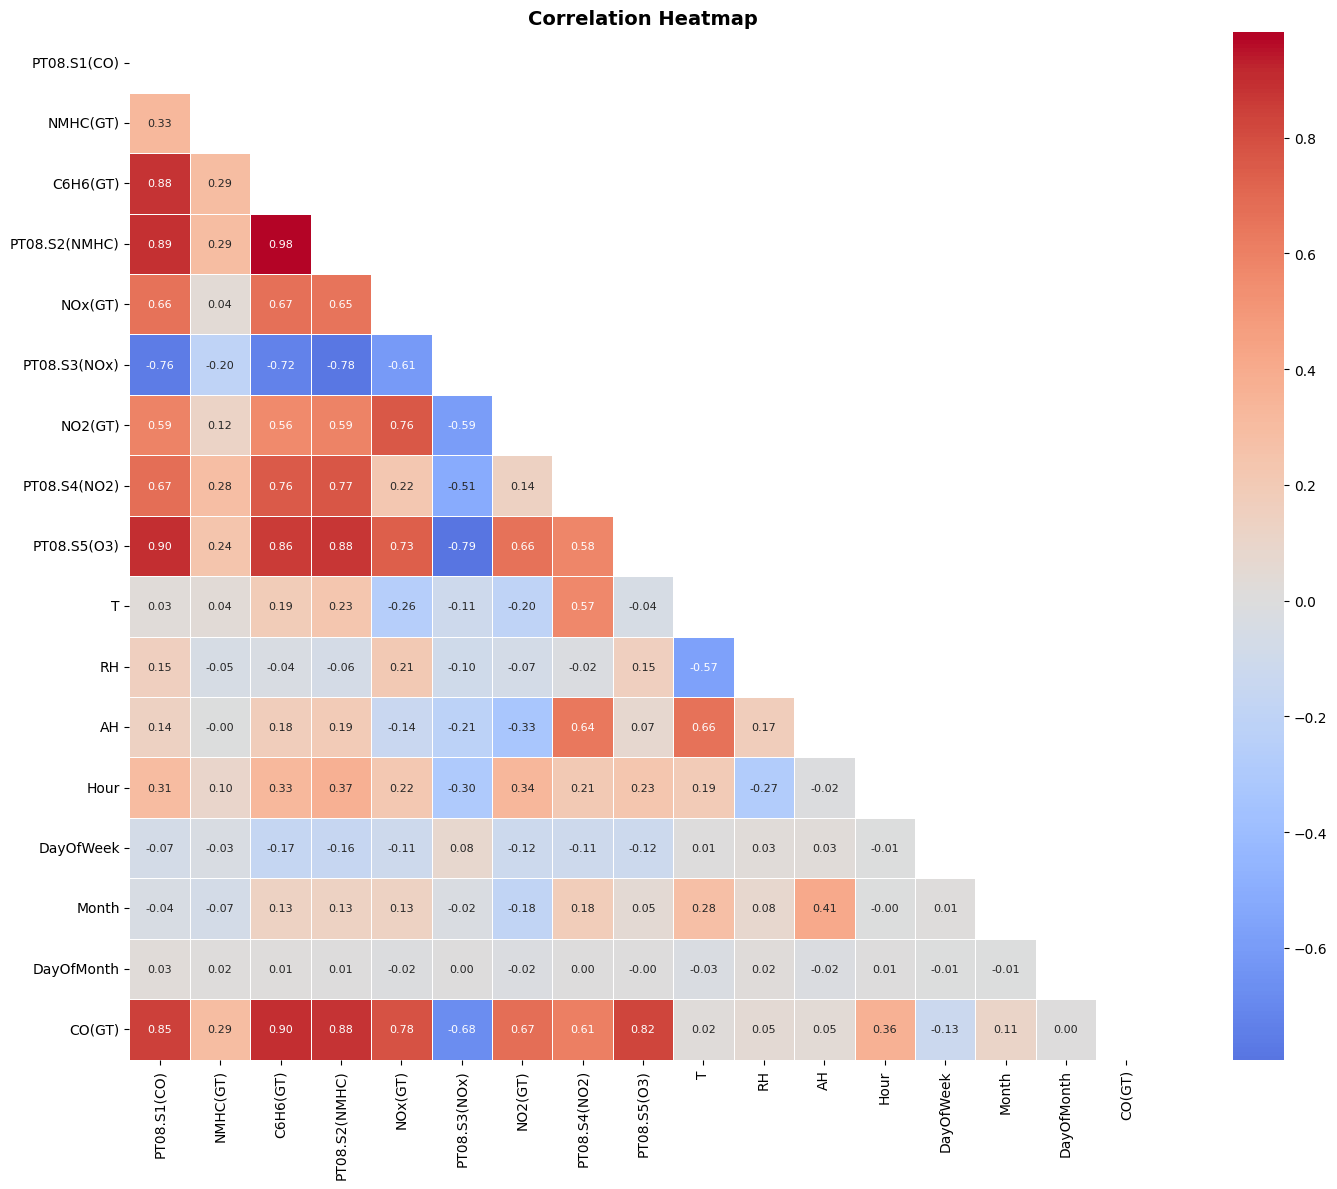

Plot 2 displayed: Correlation heatmap

Top features correlated with CO(GT):
C6H6(GT)         0.895522
PT08.S2(NMHC)    0.883407
PT08.S1(CO)      0.847234
PT08.S5(O3)      0.823608
NOx(GT)          0.784878
NO2(GT)          0.670218
PT08.S4(NO2)     0.609966
Hour             0.358159
Name: CO(GT), dtype: float64


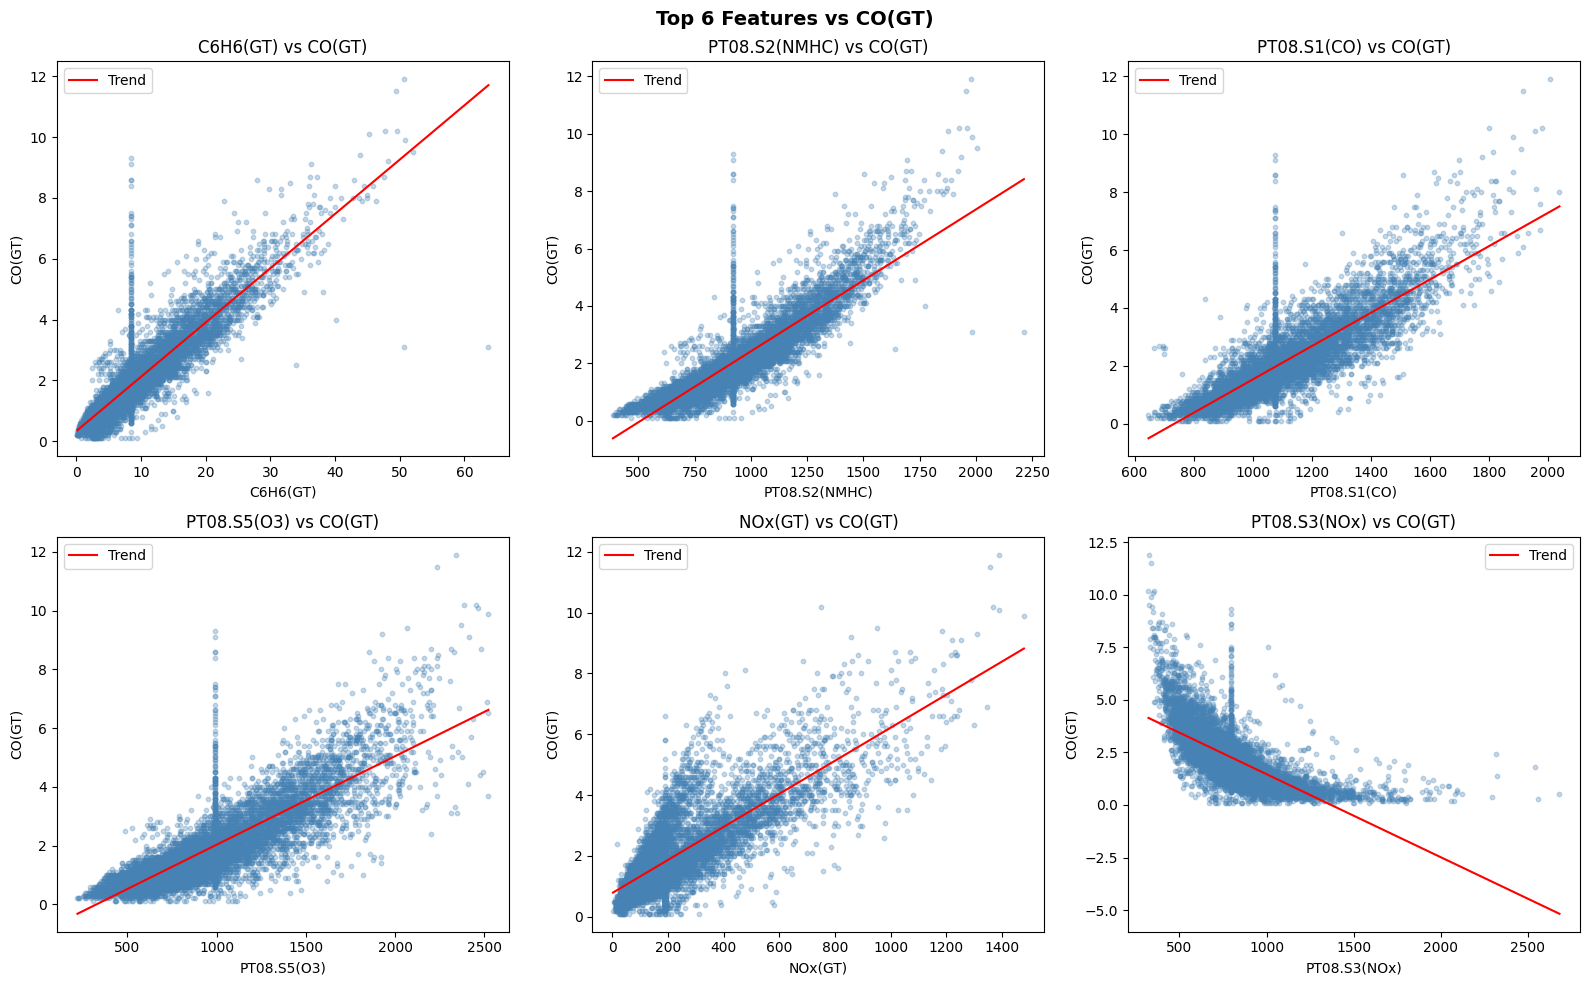

Plot 3 displayed: Scatter plots of top features


In [10]:
# ============================================================
# CELL 6: Data Visualization - Part 1
# ============================================================

# Plot 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Variable Distribution - CO(GT)", fontsize=15, fontweight='bold')

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Histogram of CO(GT)")
axes[0].set_xlabel("CO Concentration")
axes[0].set_ylabel("Frequency")
axes[0].axvline(y.mean(), color='red', linestyle='--', label="Mean")
axes[0].axvline(y.median(), color='orange', linestyle='--', label="Median")
axes[0].legend()

axes[1].boxplot(y, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title("Box Plot of CO(GT)")
axes[1].set_ylabel("CO Concentration")

plt.tight_layout()
plt.show()
print("Plot 1 displayed: Target distribution")

# Plot 2: Correlation Heatmap
corr_cols = feature_cols + [target]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Plot 2 displayed: Correlation heatmap")

target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
print("\nTop features correlated with CO(GT):")
print(target_corr.head(8))

# Plot 3: Scatter plots of top features
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Top 6 Features vs CO(GT)", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df[target], alpha=0.3, color='steelblue', s=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("CO(GT)")
    axes[i].set_title(feat + " vs CO(GT)")
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), target], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.5, label='Trend')
    axes[i].legend()

plt.tight_layout()
plt.show()
print("Plot 3 displayed: Scatter plots of top features")

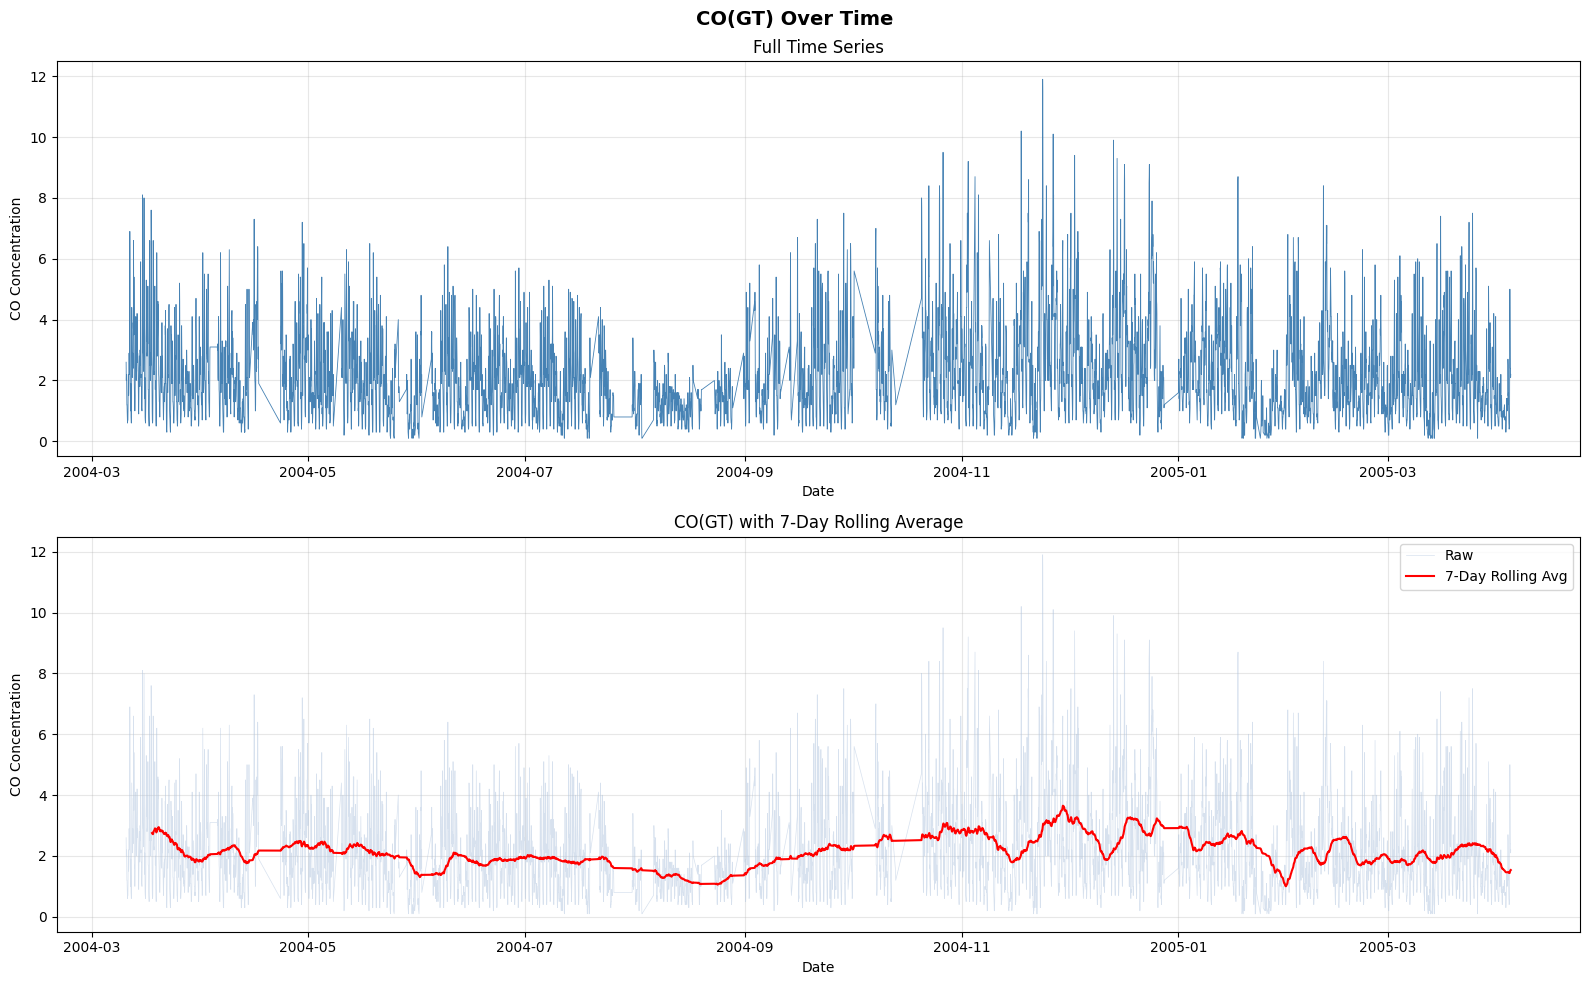

Plot 4 displayed: Time series


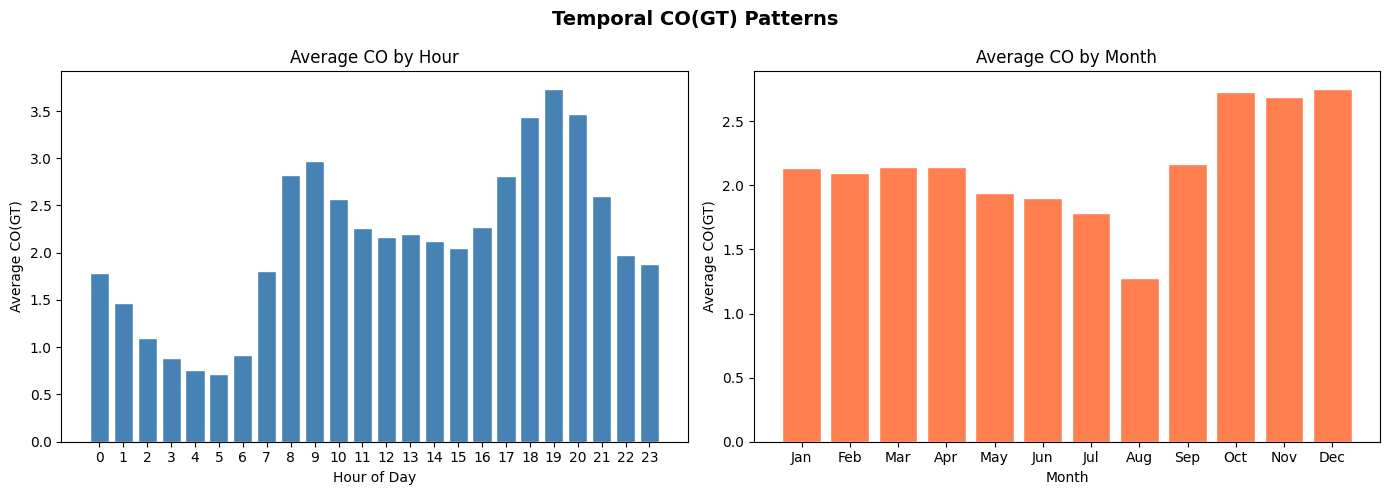

Plot 5 displayed: Temporal patterns

Peak hour: 19.0 with avg CO: 3.733
Low hour: 5.0 with avg CO: 0.713


In [11]:
# CELL 7: Data Visualization - Part 2

df_sorted = df.sort_values('DateTime')

# Plot 4: Time Series
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("CO(GT) Over Time", fontsize=14, fontweight='bold')

axes[0].plot(df_sorted['DateTime'], df_sorted['CO(GT)'], color='steelblue', linewidth=0.6)
axes[0].set_title("Full Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("CO Concentration")
axes[0].grid(True, alpha=0.3)

df_ts = df_sorted.set_index('DateTime')
rolling = df_ts['CO(GT)'].rolling(window=168).mean()
axes[1].plot(df_ts.index, df_ts['CO(GT)'], color='lightsteelblue', linewidth=0.5, alpha=0.5, label='Raw')
axes[1].plot(rolling.index, rolling.values, color='red', linewidth=1.5, label='7-Day Rolling Avg')
axes[1].set_title("CO(GT) with 7-Day Rolling Average")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("CO Concentration")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Plot 4 displayed: Time series")

# Plot 5: Temporal Patterns
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Temporal CO(GT) Patterns", fontsize=14, fontweight='bold')

hourly_avg = df.groupby('Hour')['CO(GT)'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title("Average CO by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average CO(GT)")
axes[0].set_xticks(range(0, 24))

monthly_avg = df.groupby('Month')['CO(GT)'].mean()
months_present = [month_names[int(m)-1] for m in monthly_avg.index]
axes[1].bar(months_present, monthly_avg.values, color='coral', edgecolor='white')
axes[1].set_title("Average CO by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average CO(GT)")

plt.tight_layout()
plt.show()
print("Plot 5 displayed: Temporal patterns")

print("\nPeak hour:", hourly_avg.idxmax(), "with avg CO:", round(hourly_avg.max(), 3))
print("Low hour:", hourly_avg.idxmin(), "with avg CO:", round(hourly_avg.min(), 3))

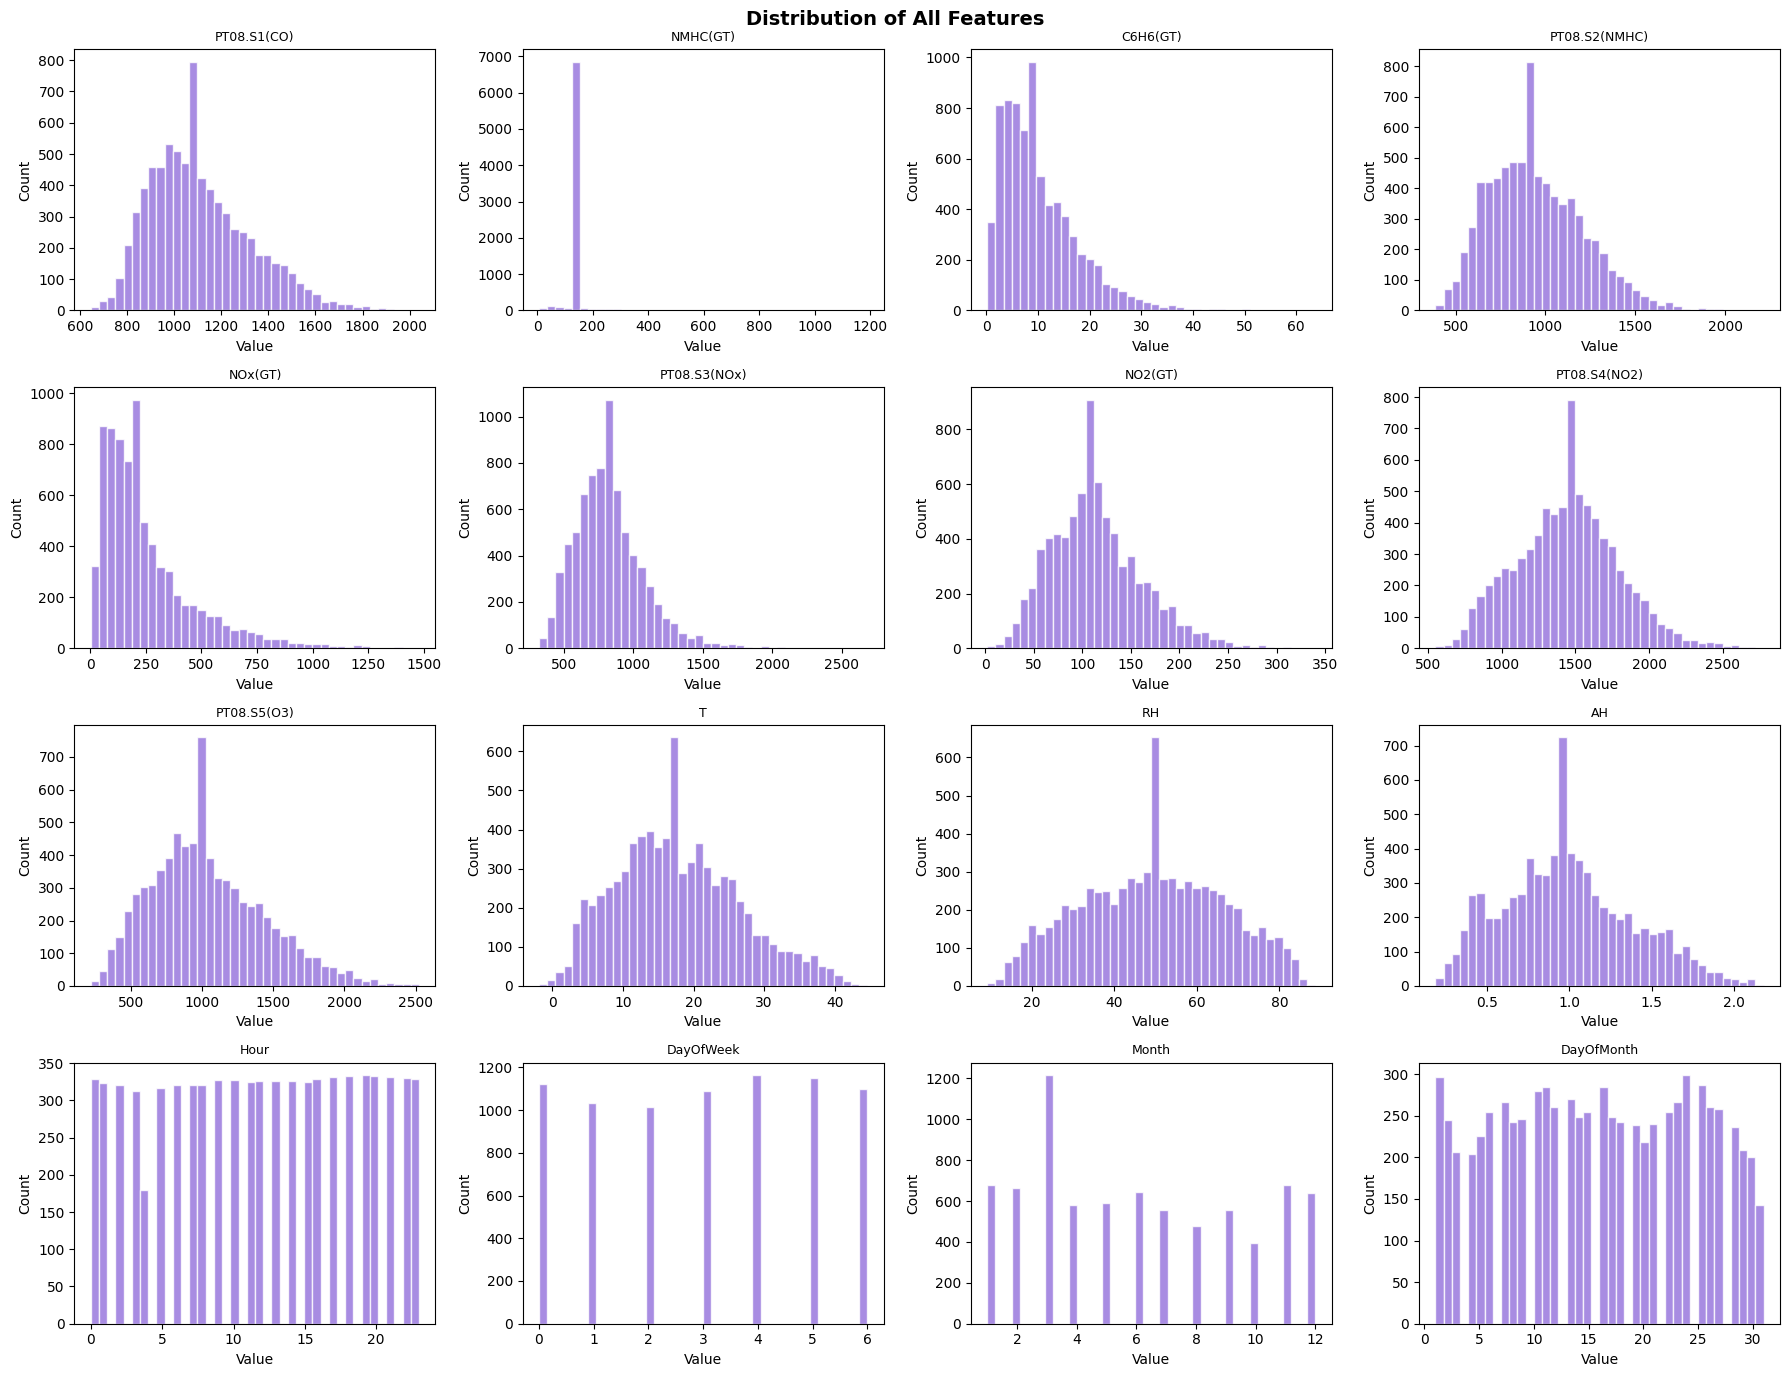

Plot 6 displayed: Feature distributions


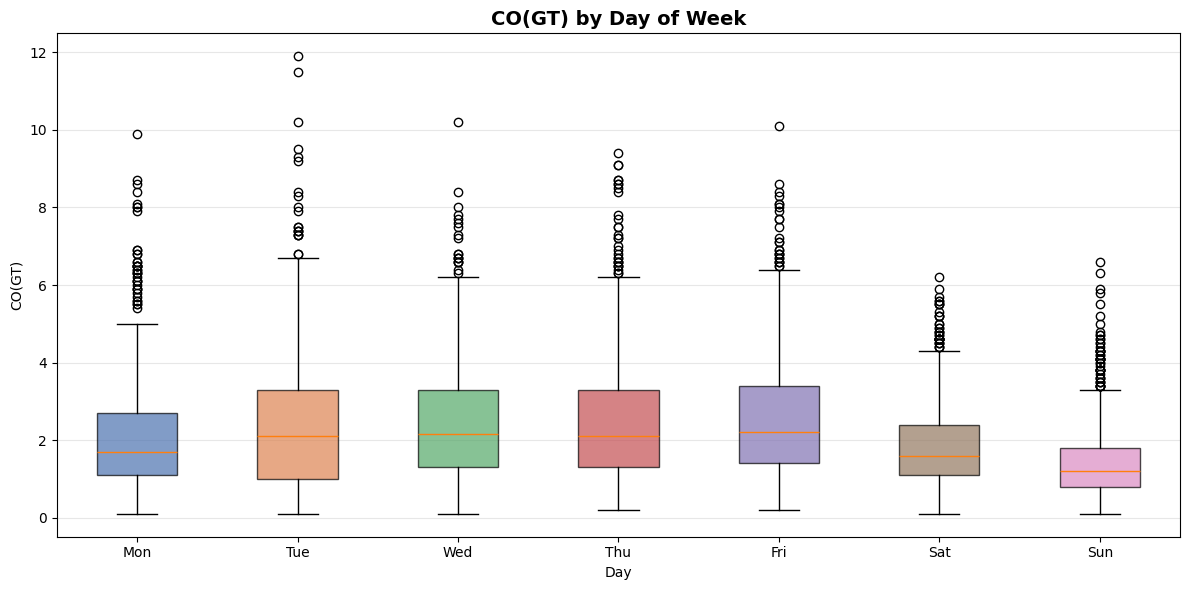

Plot 7 displayed: Day of week patterns


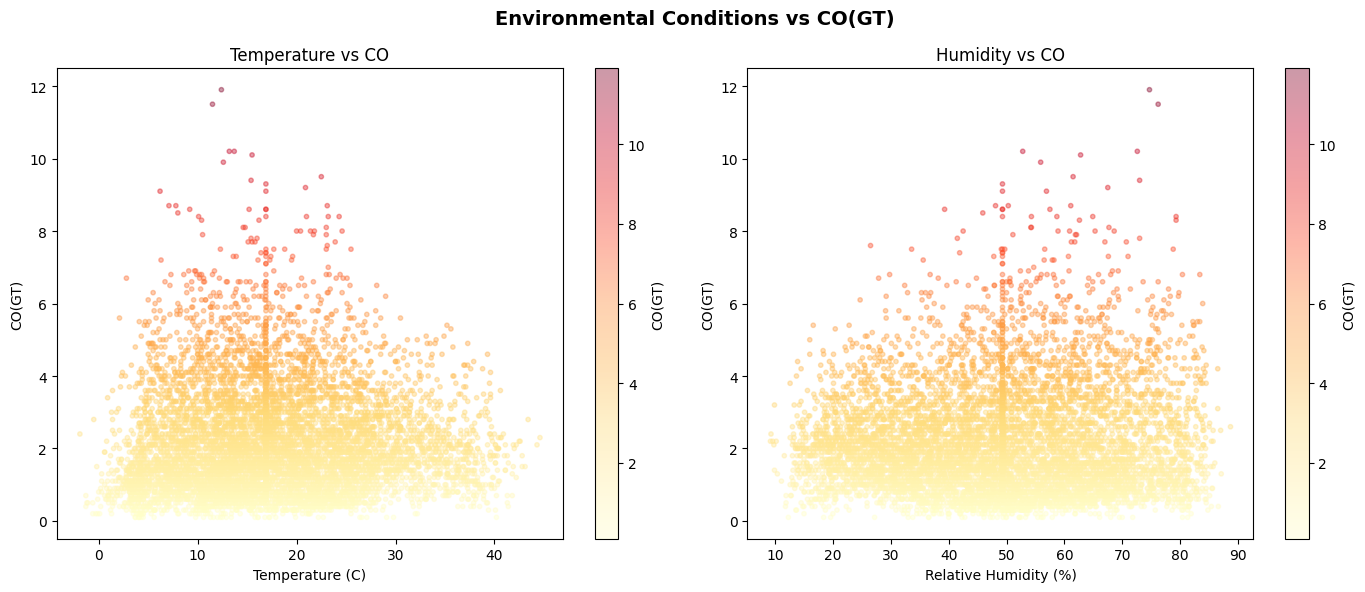

Plot 8 displayed: Weather vs CO


In [12]:
# CELL 8: Data Visualization - Part 3

# Plot 6: Feature Distributions
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("Distribution of All Features", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
print("Plot 6 displayed: Feature distributions")

# Plot 7: Box Plots by Day of Week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
grouped_data = [df[df['DayOfWeek'] == i]['CO(GT)'].values for i in range(7)]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(grouped_data, patch_artist=True, labels=day_labels)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("CO(GT) by Day of Week", fontsize=14, fontweight='bold')
ax.set_xlabel("Day")
ax.set_ylabel("CO(GT)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("Plot 7 displayed: Day of week patterns")

# Plot 8: Weather vs CO
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Environmental Conditions vs CO(GT)", fontsize=14, fontweight='bold')

sc1 = axes[0].scatter(df['T'], df['CO(GT)'], c=df['CO(GT)'], cmap='YlOrRd', alpha=0.4, s=10)
plt.colorbar(sc1, ax=axes[0], label='CO(GT)')
axes[0].set_title("Temperature vs CO")
axes[0].set_xlabel("Temperature (C)")
axes[0].set_ylabel("CO(GT)")

sc2 = axes[1].scatter(df['RH'], df['CO(GT)'], c=df['CO(GT)'], cmap='YlOrRd', alpha=0.4, s=10)
plt.colorbar(sc2, ax=axes[1], label='CO(GT)')
axes[1].set_title("Humidity vs CO")
axes[1].set_xlabel("Relative Humidity (%)")
axes[1].set_ylabel("CO(GT)")

plt.tight_layout()
plt.show()
print("Plot 8 displayed: Weather vs CO")

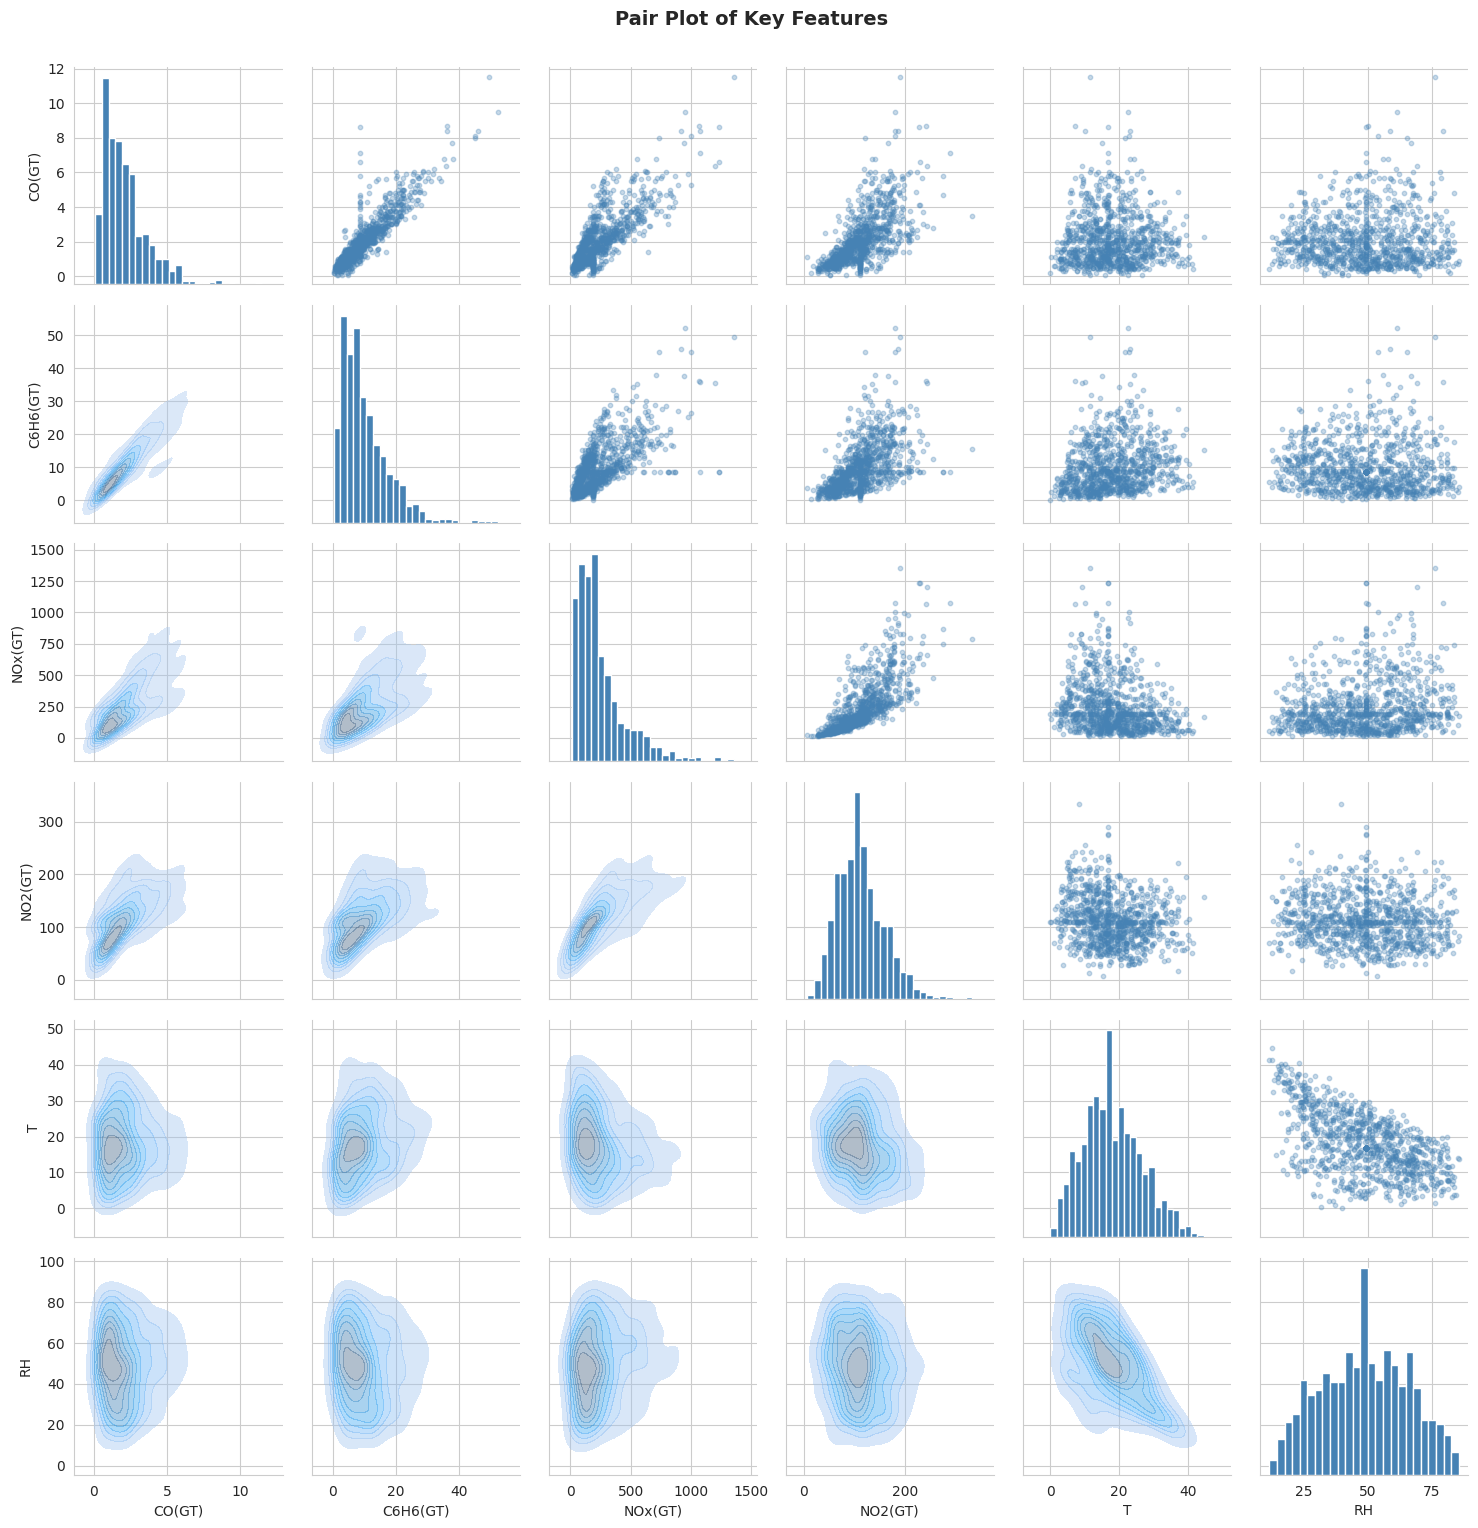

Plot 9 displayed: Pair plot (1000 samples)


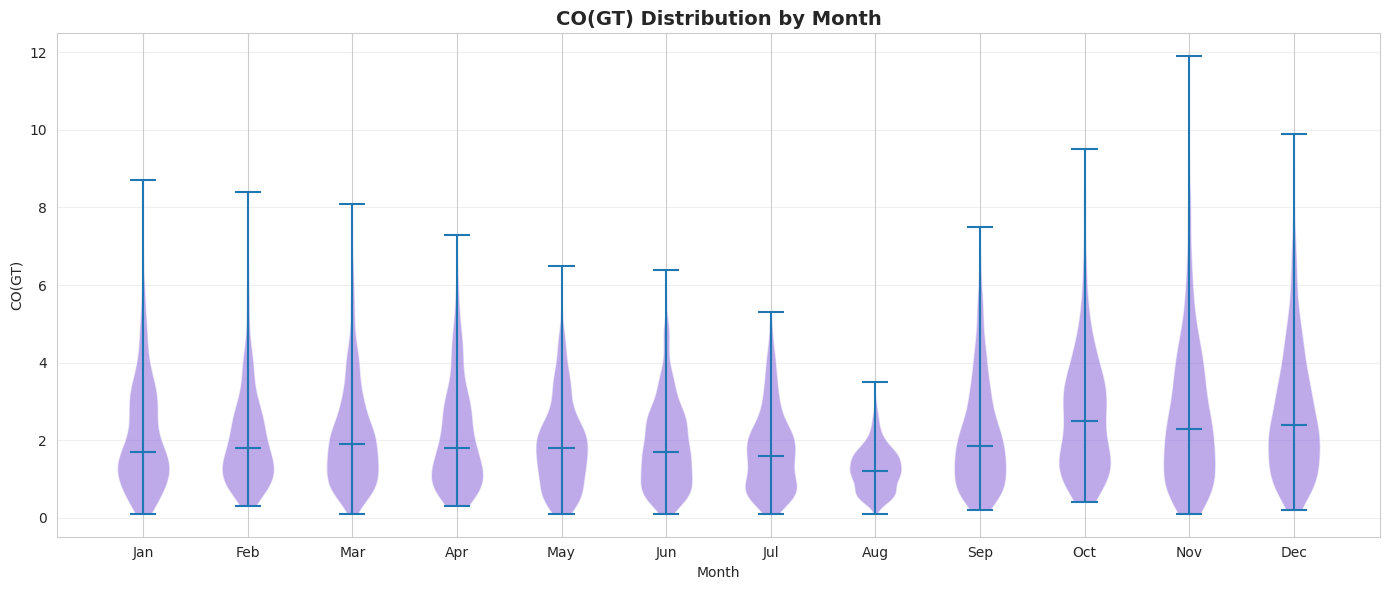

Plot 10 displayed: Monthly violin plots


In [13]:
# CELL 9: Data Visualization - Part 4

# Plot 9: Pair Plot
pair_features = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']
sample_df = df[pair_features].sample(n=min(1000, len(df)), random_state=42)

sns.set_style("whitegrid")
pair_grid = sns.PairGrid(sample_df, diag_sharey=False)
pair_grid.map_upper(plt.scatter, alpha=0.3, s=10, color='steelblue')
pair_grid.map_lower(sns.kdeplot, fill=True, alpha=0.4)
pair_grid.map_diag(plt.hist, bins=25, color='steelblue', edgecolor='white')
pair_grid.fig.suptitle("Pair Plot of Key Features", y=1.02, fontsize=14, fontweight='bold')
plt.show()
print("Plot 9 displayed: Pair plot (1000 samples)")

# Plot 10: Violin Plots by Month
month_data = [df[df['Month'] == m]['CO(GT)'].values for m in sorted(df['Month'].unique())]
month_labels_present = [month_names[int(m)-1] for m in sorted(df['Month'].unique())]

fig, ax = plt.subplots(figsize=(14, 6))
vp = ax.violinplot(month_data, positions=range(1, len(month_data)+1), showmedians=True)
for body in vp['bodies']:
    body.set_facecolor('mediumpurple')
    body.set_alpha(0.6)
ax.set_xticks(range(1, len(month_data)+1))
ax.set_xticklabels(month_labels_present)
ax.set_title("CO(GT) Distribution by Month", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("CO(GT)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("Plot 10 displayed: Monthly violin plots")

In [14]:
# CELL 10: Train-Test Split and Feature Scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData split completed:")
print("  Training samples:", len(y_train), "- 80%")
print("  Testing samples:", len(y_test), "- 20%")
print("\nFeature scaling applied using StandardScaler")
print("  Scaled to mean=0, std=1")
print("\nTraining set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Data split completed:
  Training samples: 6139 - 80%
  Testing samples: 1535 - 20%

Feature scaling applied using StandardScaler
  Scaled to mean=0, std=1

Training set shape: (6139, 16)
Testing set shape: (1535, 16)


In [15]:
# CELL 11: Train all regression models

print("\nTraining Model 1: Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest trained successfully")

print("\nTraining Model 2: Support Vector Regressor...")
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)
print("SVR trained successfully")

print("\nTraining Model 3: XGBoost Regressor...")
xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
print("XGBoost trained successfully")

print("\nTraining Model 4: Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
print("Gradient Boosting trained successfully")

print("\nAll 4 models trained successfully!")


Training Model 1: Random Forest Regressor...
Random Forest trained successfully

Training Model 2: Support Vector Regressor...
SVR trained successfully

Training Model 3: XGBoost Regressor...
XGBoost trained successfully

Training Model 4: Gradient Boosting Regressor...
Gradient Boosting trained successfully

All 4 models trained successfully!



Model Performance Comparison (sorted by R2):
            Model   RMSE    MAE     R2
          XGBoost 0.2879 0.1894 0.9602
              SVR 0.2947 0.1812 0.9583
Gradient Boosting 0.3182 0.2096 0.9514
    Random Forest 0.3518 0.2208 0.9406

Best model: XGBoost
Best R2: 0.9602


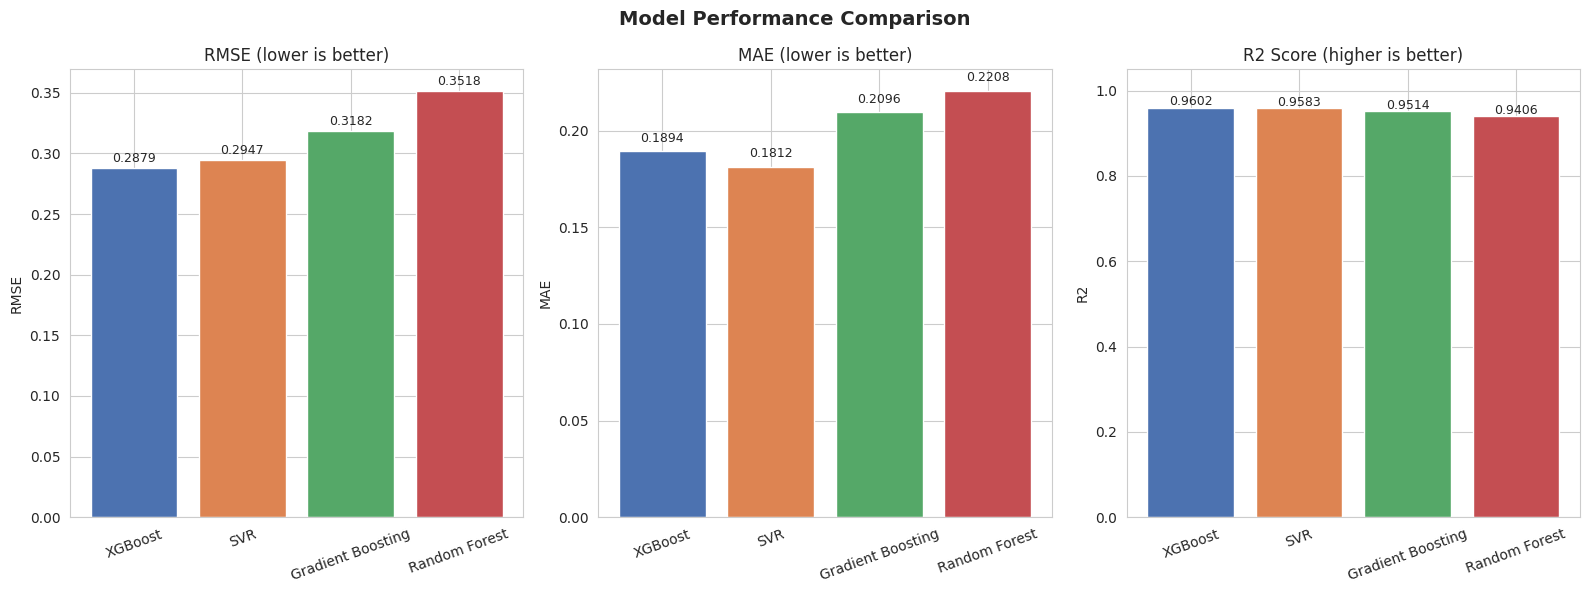

Plot 11 displayed: Model comparison


In [16]:
# CELL 12: Model evaluation and comparison

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

results_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVR', 'XGBoost', 'Gradient Boosting'],
    'RMSE': [rf_rmse, svr_rmse, xgb_rmse, gb_rmse],
    'MAE': [rf_mae, svr_mae, xgb_mae, gb_mae],
    'R2': [rf_r2, svr_r2, xgb_r2, gb_r2]
})

results_df = results_df.round(4).sort_values('R2', ascending=False).reset_index(drop=True)

print("\nModel Performance Comparison (sorted by R2):")
print(results_df.to_string(index=False))
print("\nBest model:", results_df.iloc[0]['Model'])
print("Best R2:", results_df.iloc[0]['R2'])

# Plot 11: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
models = results_df['Model'].tolist()

axes[0].bar(models, results_df['RMSE'], color=colors, edgecolor='white')
axes[0].set_title("RMSE (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(i, v + 0.005, str(v), ha='center', fontsize=9)

axes[1].bar(models, results_df['MAE'], color=colors, edgecolor='white')
axes[1].set_title("MAE (lower is better)")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['MAE']):
    axes[1].text(i, v + 0.005, str(v), ha='center', fontsize=9)

axes[2].bar(models, results_df['R2'], color=colors, edgecolor='white')
axes[2].set_title("R2 Score (higher is better)")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylim(0, 1.05)
for i, v in enumerate(results_df['R2']):
    axes[2].text(i, v + 0.005, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Plot 11 displayed: Model comparison")

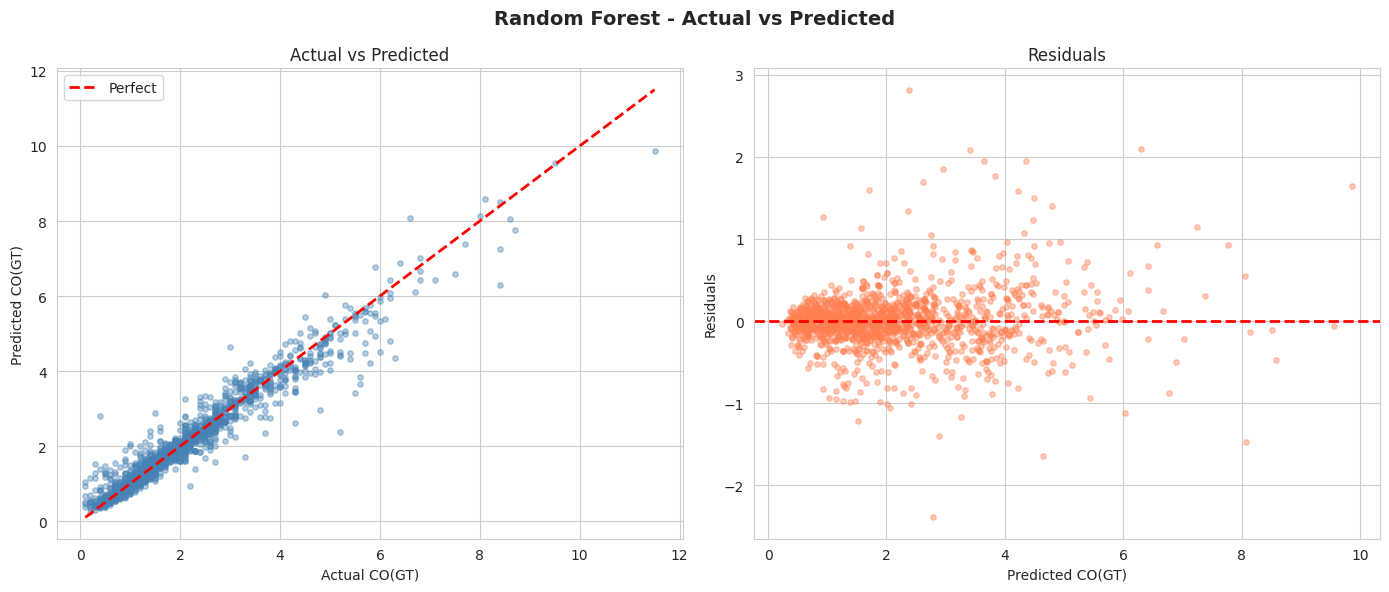

Plot 12 displayed: RF actual vs predicted


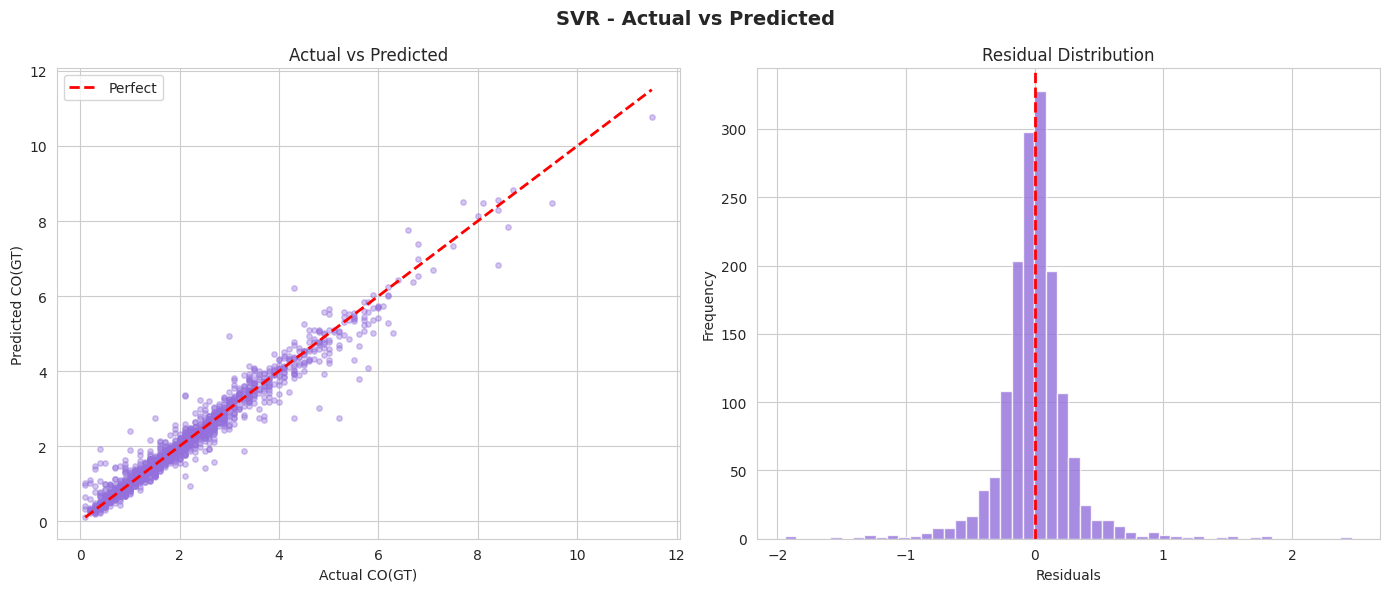

Plot 13 displayed: SVR actual vs predicted


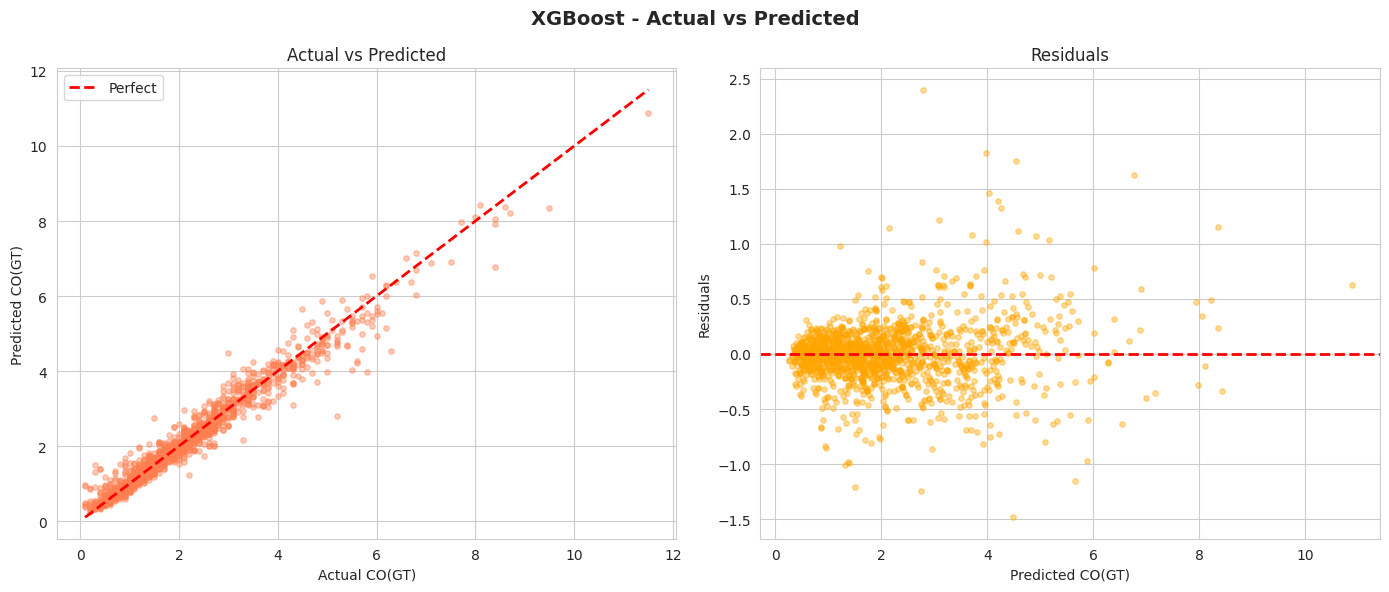

Plot 14 displayed: XGBoost actual vs predicted


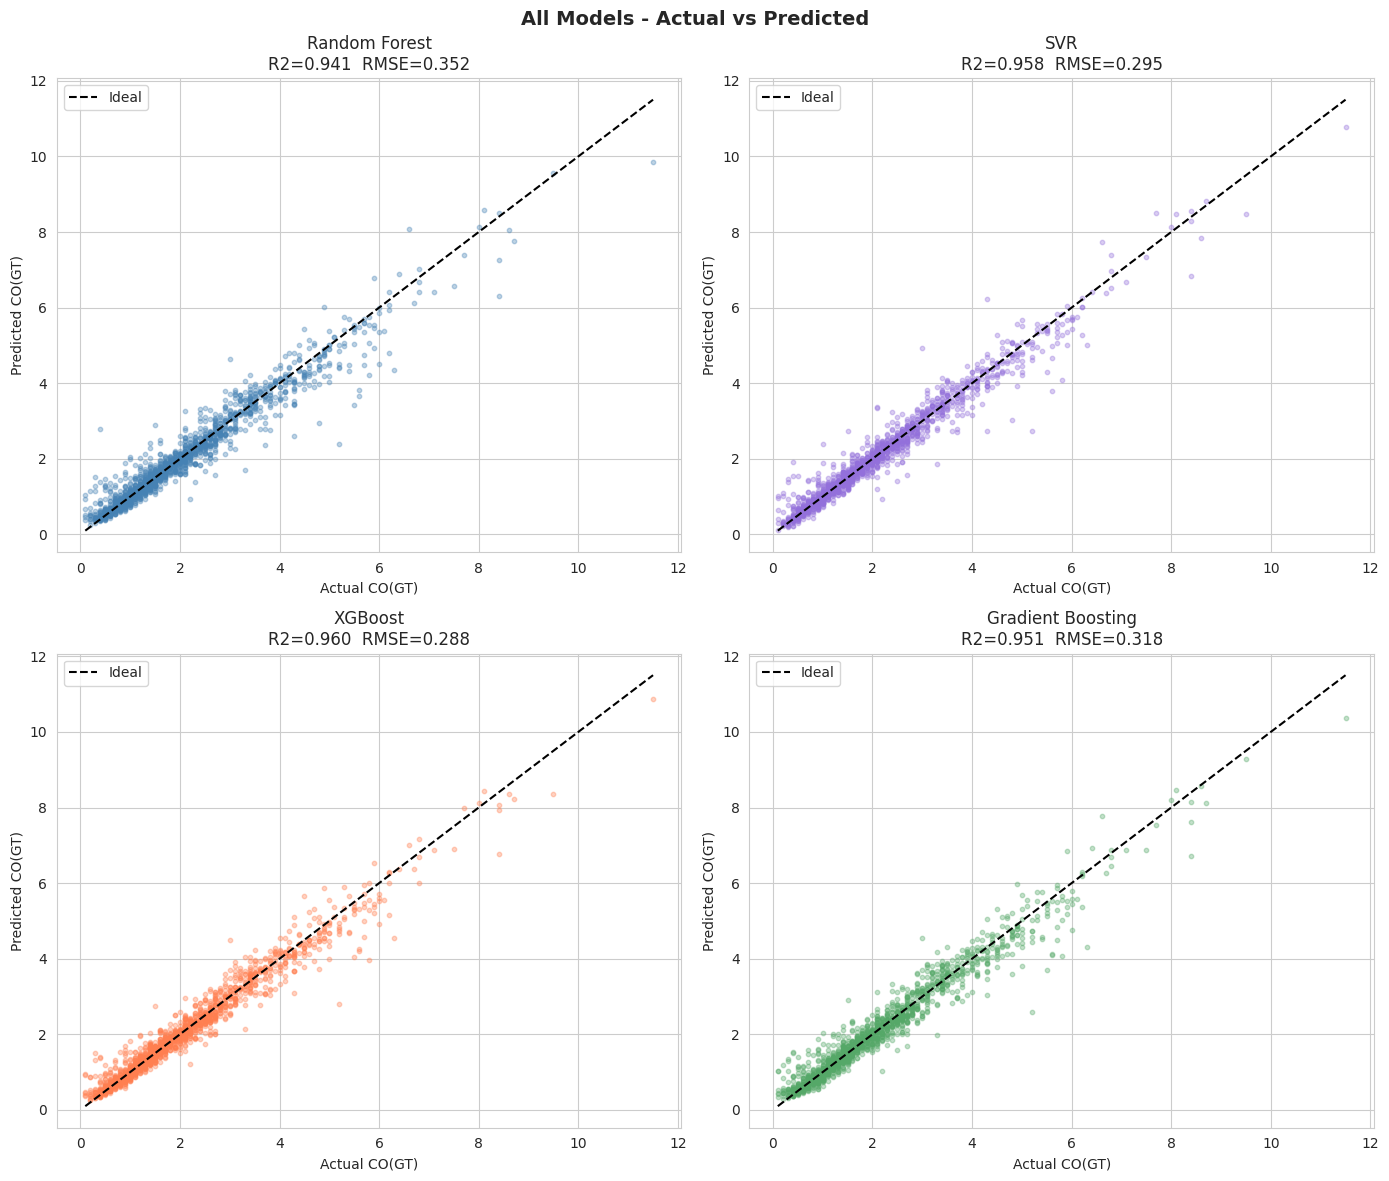

Plot 15 displayed: All models combined


In [17]:
# CELL 13: Actual vs Predicted - Individual Models

min_val = min(y_test.min(), min(rf_pred.min(), svr_pred.min(), xgb_pred.min(), gb_pred.min()))
max_val = max(y_test.max(), max(rf_pred.max(), svr_pred.max(), xgb_pred.max(), gb_pred.max()))

# Plot 12: Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Random Forest - Actual vs Predicted", fontsize=14, fontweight='bold')

axes[0].scatter(y_test, rf_pred, alpha=0.4, color='steelblue', s=15)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual CO(GT)")
axes[0].set_ylabel("Predicted CO(GT)")
axes[0].legend()

residuals = y_test.values - rf_pred
axes[1].scatter(rf_pred, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residuals")
axes[1].set_xlabel("Predicted CO(GT)")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()
print("Plot 12 displayed: RF actual vs predicted")

# Plot 13: SVR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SVR - Actual vs Predicted", fontsize=14, fontweight='bold')

axes[0].scatter(y_test, svr_pred, alpha=0.4, color='mediumpurple', s=15)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual CO(GT)")
axes[0].set_ylabel("Predicted CO(GT)")
axes[0].legend()

svr_residuals = y_test.values - svr_pred
axes[1].hist(svr_residuals, bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
print("Plot 13 displayed: SVR actual vs predicted")

# Plot 14: XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("XGBoost - Actual vs Predicted", fontsize=14, fontweight='bold')

axes[0].scatter(y_test, xgb_pred, alpha=0.4, color='coral', s=15)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual CO(GT)")
axes[0].set_ylabel("Predicted CO(GT)")
axes[0].legend()

xgb_residuals = y_test.values - xgb_pred
axes[1].scatter(xgb_pred, xgb_residuals, alpha=0.4, color='orange', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residuals")
axes[1].set_xlabel("Predicted CO(GT)")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()
print("Plot 14 displayed: XGBoost actual vs predicted")

# Plot 15: All Models Combined
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("All Models - Actual vs Predicted", fontsize=14, fontweight='bold')

model_info = [
    ('Random Forest', rf_pred, 'steelblue'),
    ('SVR', svr_pred, 'mediumpurple'),
    ('XGBoost', xgb_pred, 'coral'),
    ('Gradient Boosting', gb_pred, '#55A868')
]

for ax, (name, pred, color) in zip(axes.flatten(), model_info):
    ax.scatter(y_test, pred, alpha=0.35, color=color, s=10)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Ideal')
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.set_title(f"{name}\nR2={r2:.3f}  RMSE={rmse:.3f}")
    ax.set_xlabel("Actual CO(GT)")
    ax.set_ylabel("Predicted CO(GT)")
    ax.legend()

plt.tight_layout()
plt.show()
print("Plot 15 displayed: All models combined")

In [18]:
# CELL 14: Create actual vs predicted results dataframe

results_table = pd.DataFrame({
    'Actual_CO_GT': y_test.values,
    'RF_Predicted': rf_pred.round(3),
    'SVR_Predicted': svr_pred.round(3),
    'XGB_Predicted': xgb_pred.round(3),
    'GB_Predicted': gb_pred.round(3),
    'RF_Error': (y_test.values - rf_pred).round(3),
    'XGB_Error': (y_test.values - xgb_pred).round(3)
}).reset_index(drop=True)

print("\nActual vs Predicted Results (first 30 rows):")
print(results_table.head(30).to_string(index=True))

print("\nDataframe statistics:")
print("  Total test samples:", len(results_table))
print("  Mean absolute errors:")
print("    Random Forest:", round(results_table['RF_Error'].abs().mean(), 4))
print("    XGBoost:", round(results_table['XGB_Error'].abs().mean(), 4))

results_table.to_csv("actual_vs_predicted_results.csv", index=False)
print("\nResults saved to: actual_vs_predicted_results.csv")

from google.colab import files
files.download("actual_vs_predicted_results.csv")
print("CSV downloaded to your computer!")


Actual vs Predicted Results (first 30 rows):
    Actual_CO_GT  RF_Predicted  SVR_Predicted  XGB_Predicted  GB_Predicted  RF_Error  XGB_Error
0            7.1         6.425          6.685          6.885         6.863     0.675      0.215
1            0.9         0.858          0.897          0.854         0.908     0.042      0.046
2            3.8         3.435          3.422          3.170         3.262     0.365      0.630
3            2.3         1.857          1.848          2.236         2.123     0.443      0.064
4            0.9         0.900          0.885          0.833         0.834    -0.000      0.067
5            2.2         2.282          2.389          2.276         2.375    -0.082     -0.076
6            5.6         3.832          3.794          4.205         4.096     1.768      1.395
7            1.6         1.941          1.737          1.653         1.579    -0.341     -0.053
8            3.1         2.947          3.053          2.929         2.981     0.153      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV downloaded to your computer!


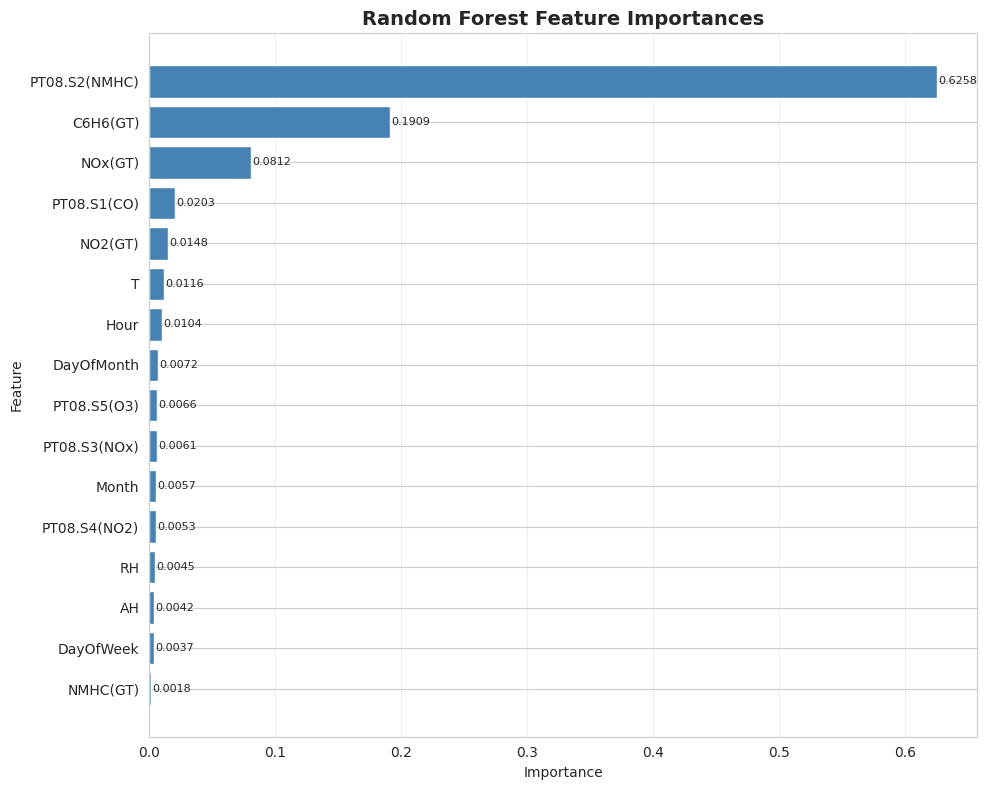

Plot 16 displayed: RF feature importance


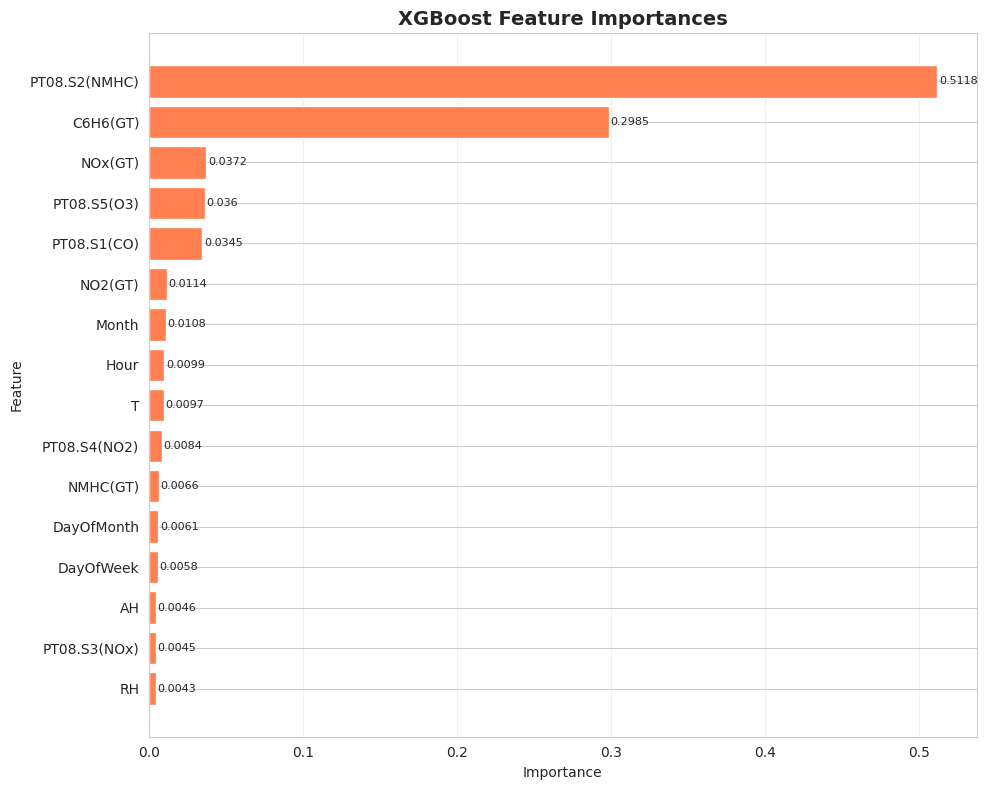

Plot 17 displayed: XGBoost feature importance


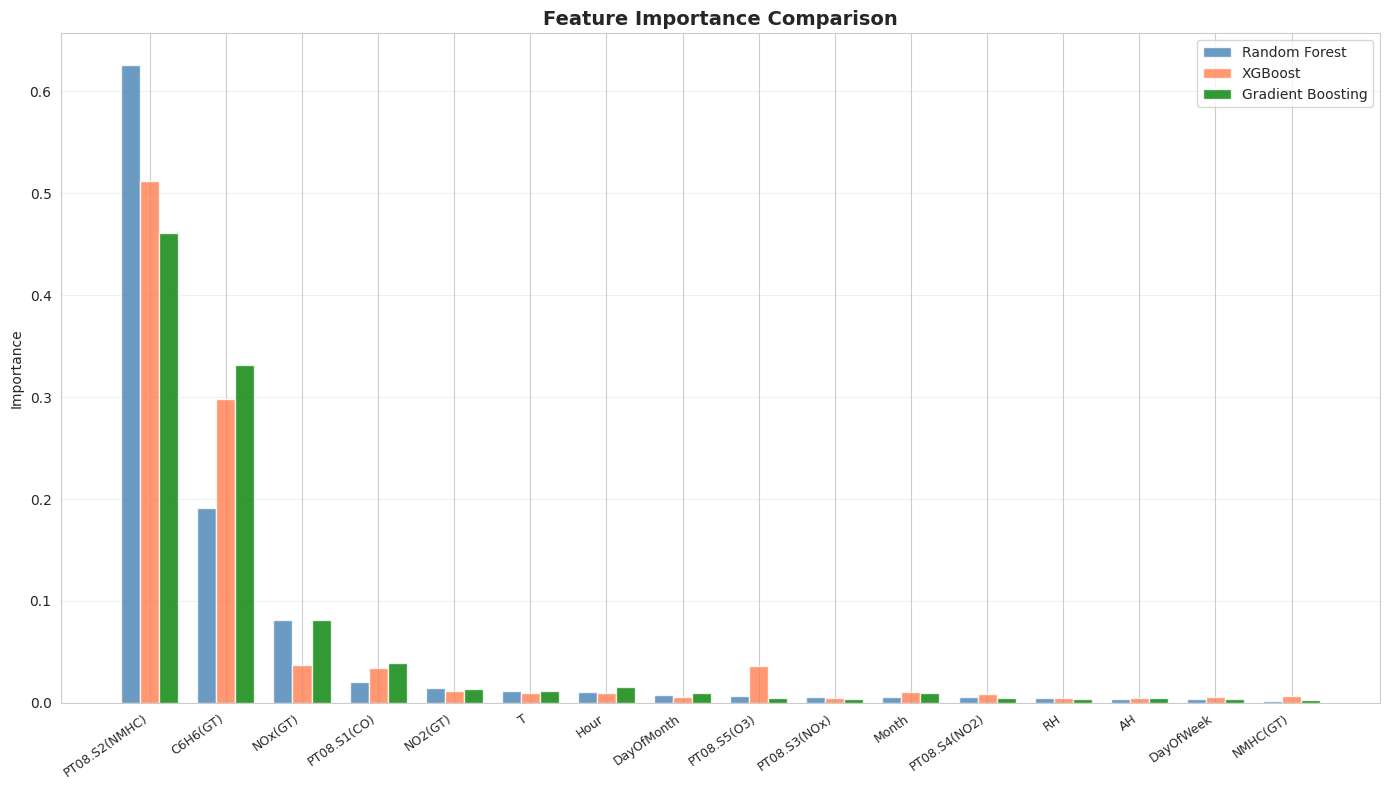

Plot 18 displayed: Feature importance comparison

Top 5 features (Random Forest):
      Feature  Importance
PT08.S2(NMHC)    0.625777
     C6H6(GT)    0.190938
      NOx(GT)    0.081182
  PT08.S1(CO)    0.020325
      NO2(GT)    0.014831


In [19]:
# CELL 15: Feature importance analysis

# Plot 16: Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue', edgecolor='white')
ax.set_title("Random Forest Feature Importances", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, rf_importance['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, str(round(val, 4)), va='center', fontsize=8)
plt.tight_layout()
plt.show()
print("Plot 16 displayed: RF feature importance")

# Plot 17: XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(xgb_importance['Feature'], xgb_importance['Importance'], color='coral', edgecolor='white')
ax.set_title("XGBoost Feature Importances", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, xgb_importance['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, str(round(val, 4)), va='center', fontsize=8)
plt.tight_layout()
plt.show()
print("Plot 17 displayed: XGBoost feature importance")

# Plot 18: Combined Feature Importance
rf_imp = pd.DataFrame({
    'Feature': feature_cols,
    'RF': rf_model.feature_importances_,
    'XGB': xgb_model.feature_importances_,
    'GB': gb_model.feature_importances_
}).sort_values('RF', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(feature_cols))
width = 0.25

ax.bar(x - width, rf_imp['RF'], width, label='Random Forest', color='steelblue', alpha=0.8)
ax.bar(x, rf_imp['XGB'], width, label='XGBoost', color='coral', alpha=0.8)
ax.bar(x + width, rf_imp['GB'], width, label='Gradient Boosting', color='green', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(rf_imp['Feature'], rotation=35, ha='right', fontsize=9)
ax.set_title("Feature Importance Comparison", fontsize=14, fontweight='bold')
ax.set_ylabel("Importance")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("Plot 18 displayed: Feature importance comparison")

print("\nTop 5 features (Random Forest):")
print(rf_importance.sort_values('Importance', ascending=False).head(5).to_string(index=False))


Performing 5-Fold Cross-Validation...

Cross-Validation R2 Scores:
Random Forest: [np.float64(0.9321), np.float64(0.9328), np.float64(0.9205), np.float64(0.9318), np.float64(0.9344)] Mean: 0.9303
XGBoost: [np.float64(0.9522), np.float64(0.9509), np.float64(0.9513), np.float64(0.9511), np.float64(0.9517)] Mean: 0.9514
Gradient Boost: [np.float64(0.9465), np.float64(0.9468), np.float64(0.9446), np.float64(0.9464), np.float64(0.9479)] Mean: 0.9464


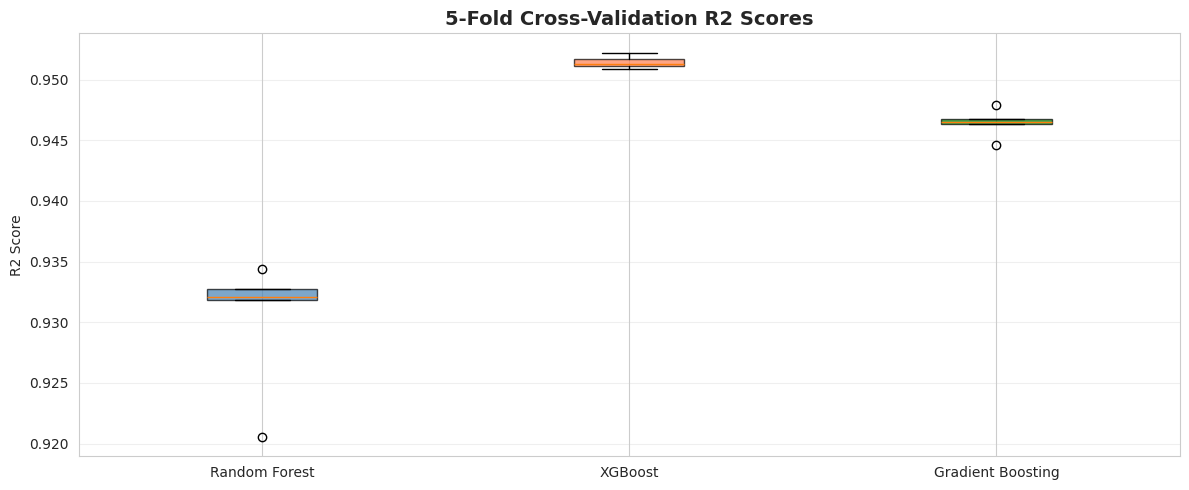

Plot 19 displayed: Cross-validation results


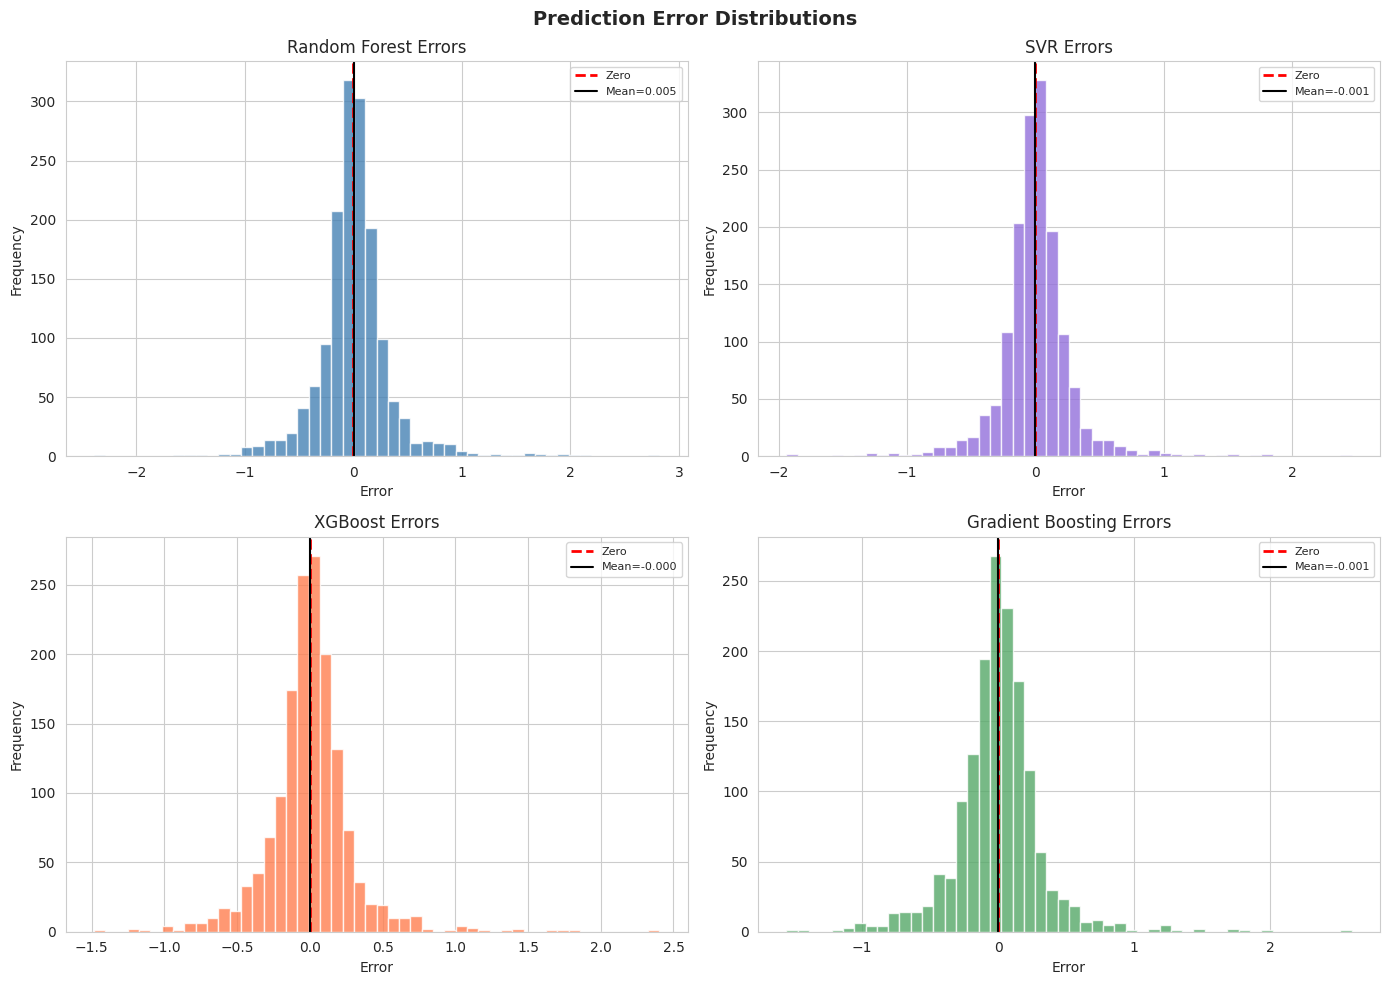

Plot 20 displayed: Error distributions

         AIR QUALITY PREDICTION - PROJECT SUMMARY

Dataset Information:
  Total records processed: 7674
  Number of features: 16
  Target variable: CO(GT) - Carbon Monoxide
  Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00

Models Trained:
  1. Random Forest
  2. SVR
  3. XGBoost
  4. Gradient Boosting

Model Performance:
            Model   RMSE    MAE     R2
          XGBoost 0.2879 0.1894 0.9602
              SVR 0.2947 0.1812 0.9583
Gradient Boosting 0.3182 0.2096 0.9514
    Random Forest 0.3518 0.2208 0.9406

Best Model: XGBoost
  R2 Score: 0.9602
  RMSE: 0.2879
  MAE: 0.1894

Top 5 Most Influential Features:
  1. PT08.S2(NMHC)
  2. C6H6(GT)
  3. NOx(GT)
  4. PT08.S1(CO)
  5. NO2(GT)

Total Visualizations Created: 20 plots
Results Downloaded: actual_vs_predicted_results.csv

Project completed successfully!


In [20]:
# CELL 16: Cross-validation and error distribution analysis

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("\nPerforming 5-Fold Cross-Validation...")
rf_cv = cross_val_score(rf_model, X_train_scaled, y_train, cv=kf, scoring='r2', n_jobs=-1)
xgb_cv = cross_val_score(xgb_model, X_train_scaled, y_train, cv=kf, scoring='r2', n_jobs=-1)
gb_cv = cross_val_score(gb_model, X_train_scaled, y_train, cv=kf, scoring='r2', n_jobs=-1)

print("\nCross-Validation R2 Scores:")
print("Random Forest:", [round(s, 4) for s in rf_cv], "Mean:", round(rf_cv.mean(), 4))
print("XGBoost:", [round(s, 4) for s in xgb_cv], "Mean:", round(xgb_cv.mean(), 4))
print("Gradient Boost:", [round(s, 4) for s in gb_cv], "Mean:", round(gb_cv.mean(), 4))

# Plot 19: Cross-Validation
fig, ax = plt.subplots(figsize=(12, 5))
cv_data = [rf_cv, xgb_cv, gb_cv]
cv_names = ['Random Forest', 'XGBoost', 'Gradient Boosting']
bp = ax.boxplot(cv_data, labels=cv_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("5-Fold Cross-Validation R2 Scores", fontsize=14, fontweight='bold')
ax.set_ylabel("R2 Score")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("Plot 19 displayed: Cross-validation results")

# Plot 20: Error Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Prediction Error Distributions", fontsize=14, fontweight='bold')

error_info = [
    ('Random Forest', y_test.values - rf_pred, 'steelblue'),
    ('SVR', y_test.values - svr_pred, 'mediumpurple'),
    ('XGBoost', y_test.values - xgb_pred, 'coral'),
    ('Gradient Boosting', y_test.values - gb_pred, '#55A868')
]

for ax, (name, errors, color) in zip(axes.flatten(), error_info):
    ax.hist(errors, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax.axvline(x=errors.mean(), color='black', linestyle='-', linewidth=1.5,
               label=f"Mean={errors.mean():.3f}")
    ax.set_title(f"{name} Errors")
    ax.set_xlabel("Error")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Plot 20 displayed: Error distributions")

# Final Summary
print("\n" + "="*70)
print("         AIR QUALITY PREDICTION - PROJECT SUMMARY")
print("="*70)

print("\nDataset Information:")
print(f"  Total records processed: {len(df)}")
print(f"  Number of features: {len(feature_cols)}")
print(f"  Target variable: CO(GT) - Carbon Monoxide")
print(f"  Date range: {df['DateTime'].min()} to {df['DateTime'].max()}")

print("\nModels Trained:")
for i, model in enumerate(['Random Forest', 'SVR', 'XGBoost', 'Gradient Boosting'], 1):
    print(f"  {i}. {model}")

print("\nModel Performance:")
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model}")
print(f"  R2 Score: {results_df.iloc[0]['R2']}")
print(f"  RMSE: {results_df.iloc[0]['RMSE']}")
print(f"  MAE: {results_df.iloc[0]['MAE']}")

top5_features = rf_importance.sort_values('Importance', ascending=False)['Feature'].head(5).tolist()
print("\nTop 5 Most Influential Features:")
for i, feat in enumerate(top5_features, 1):
    print(f"  {i}. {feat}")

print("\nTotal Visualizations Created: 20 plots")
print("Results Downloaded: actual_vs_predicted_results.csv")
print("\nProject completed successfully!")
print("="*70)